DSCI 552 Homework 5
===================

- Name: Umaeshwer Shankar
- GitHub Username: umaeshwer
- USD ID: 7601-5514-88

## Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import xgboost as xgb

## 1. Decision Trees as Interpretable Models

### (a) Download the Acute Inflamations data from https://archive.ics.uci.edu/ml/datasets/Acute+Inflammations.

In [33]:
inflammations_columns = ['temperature_of_patient', 'occurrence_of_nausea', 'lumbar_pain', 'urine_pushing', 'micturition_pains', 'burning_of_urethra_itch_swelling_of_urethra_outlet', 'decision_inflammation_of_urinary_bladder', 'decision_nephritis_of_renal_pelvis_region']
inflammations_data = pd.read_csv(
    '../data/diagnosis.data',
    header=None,
    names=inflammations_columns,
    sep=r'\s+',
    engine='python',
    encoding='utf-16'
)
inflammations_data['temperature_of_patient'] = inflammations_data['temperature_of_patient'].astype(str).str.replace(',', '.').astype(float)
inflammations_data.dropna(inplace=True)
inflammations_data = inflammations_data.reset_index(drop=True)
inflammations_data.head()


,temperature_of_patient,occurrence_of_nausea,lumbar_pain,urine_pushing,micturition_pains,burning_of_urethra_itch_swelling_of_urethra_outlet,decision_inflammation_of_urinary_bladder,decision_nephritis_of_renal_pelvis_region
0,35.5,no,yes,no,no,no,no,no
1,35.9,no,no,yes,yes,yes,yes,no
2,35.9,no,yes,no,no,no,no,no
3,36.0,no,no,yes,yes,yes,yes,no
4,36.0,no,yes,no,no,no,no,no


### (b) Build a decision tree on the whole data set and plot it.

Note: This data set is a multi-label data set. Sk-Learn seems to support building multi-label decision trees.
Alternatively, you can use the label powerset method to convert it to a multiclass data set. Also, you can
use the binary relevance method and build one decision tree for each label. It seems that the label powerset
approach is more relevant here. Is that right?

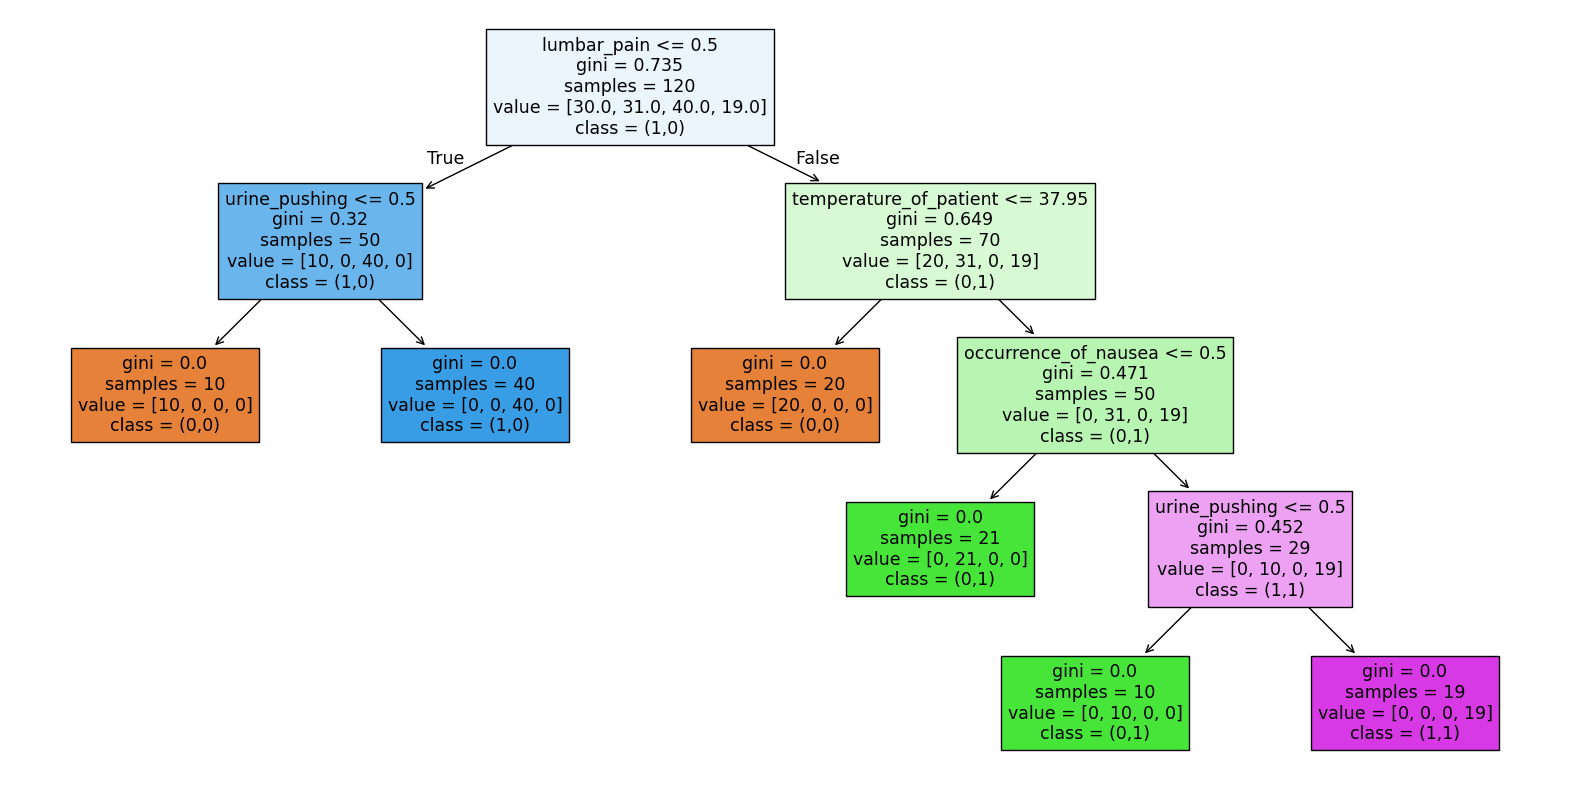

In [38]:
# Encode yes/no → 1/0
inflammations_data = inflammations_data.replace({'yes': 1, 'no': 0})

# Features
X = inflammations_data.drop([
    'decision_inflammation_of_urinary_bladder',
    'decision_nephritis_of_renal_pelvis_region'
], axis=1)

# Original multi-label target
y_multi = inflammations_data[
    ['decision_inflammation_of_urinary_bladder',
     'decision_nephritis_of_renal_pelvis_region']
]

# 🔑 Label Powerset transformation
y_lp = y_multi.apply(lambda row: row.iloc[0]*2 + row.iloc[1], axis=1)

model = DecisionTreeClassifier()
model.fit(X, y_lp)

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['(0,0)', '(0,1)', '(1,0)', '(1,1)']
)

plt.show()

### (c) Convert the decision rules into a set of IF-THEN rules.

Note: You can use the code in https://www.kdnuggets.com/2017/05/simplifying-decision-tree-interpretation-decision-rules-python.html.

In [39]:
def tree_to_pseudo(tree, feature_names):
	"""
	Outputs a decision tree model as if/then pseudocode
	
	Parameters:
	-----------
	tree: decision tree model
		The decision tree to represent as pseudocode
	feature_names: list
		The feature names of the dataset used for building the decision tree
	"""

	left = tree.tree_.children_left
	right = tree.tree_.children_right
	threshold = tree.tree_.threshold
	features = [feature_names[i] for i in tree.tree_.feature]
	value = tree.tree_.value

	def recurse(left, right, threshold, features, node, depth=0):
		indent = "  " * depth
		if (threshold[node] != -2):
			print(indent,"if ( " + features[node] + " <= " + str(threshold[node]) + " ) {")
			if left[node] != -1:
				recurse (left, right, threshold, features, left[node], depth+1)
				print(indent,"} else {")
				if right[node] != -1:
					recurse (left, right, threshold, features, right[node], depth+1)
				print(indent,"}")
		else:
			print(indent,"return " + str(value[node]))

	recurse(left, right, threshold, features, 0)

In [40]:
tree_to_pseudo(model, X.columns)

 if ( lumbar_pain <= 0.5 ) {
   if ( urine_pushing <= 0.5 ) {
     return [[1. 0. 0. 0.]]
   } else {
     return [[0. 0. 1. 0.]]
   }
 } else {
   if ( temperature_of_patient <= 37.95000076293945 ) {
     return [[1. 0. 0. 0.]]
   } else {
     if ( occurrence_of_nausea <= 0.5 ) {
       return [[0. 1. 0. 0.]]
     } else {
       if ( urine_pushing <= 0.5 ) {
         return [[0. 1. 0. 0.]]
       } else {
         return [[0. 0. 0. 1.]]
       }
     }
   }
 }


### (d) Use cost-complexity pruning to find a minimal decision tree and a set of decision rules with high interpretability.

Best alpha: 0.0
Test accuracy: 1.0
Tree depth: 4
Number of leaves: 6


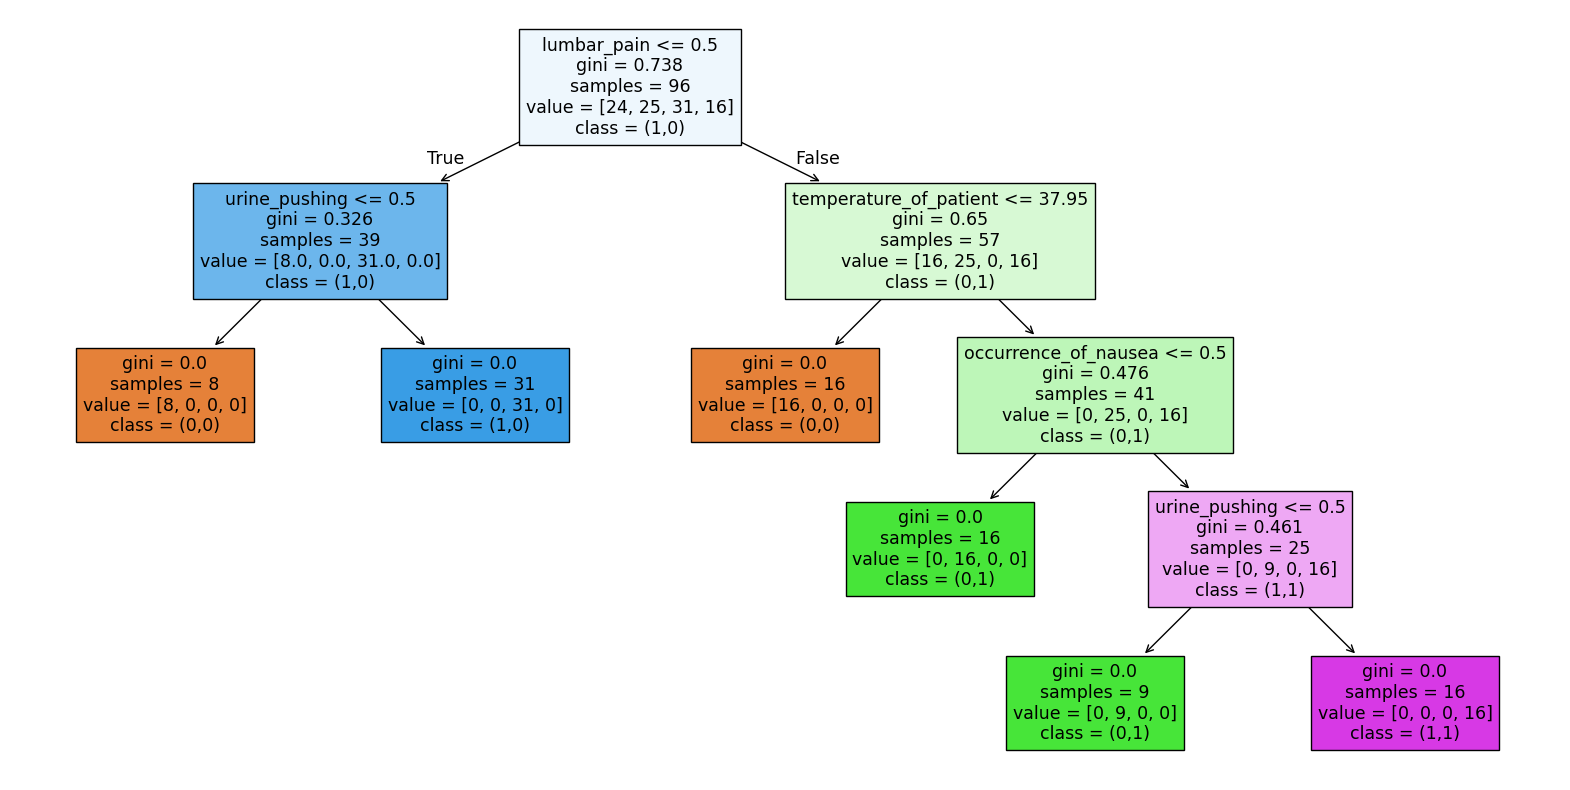

 if ( lumbar_pain <= 0.5 ) {
   if ( urine_pushing <= 0.5 ) {
     return [[1. 0. 0. 0.]]
   } else {
     return [[0. 0. 1. 0.]]
   }
 } else {
   if ( temperature_of_patient <= 37.95000076293945 ) {
     return [[1. 0. 0. 0.]]
   } else {
     if ( occurrence_of_nausea <= 0.5 ) {
       return [[0. 1. 0. 0.]]
     } else {
       if ( urine_pushing <= 0.5 ) {
         return [[0. 1. 0. 0.]]
       } else {
         return [[0. 0. 0. 1.]]
       }
     }
   }
 }


In [52]:


inflammations_columns = [
    'temperature_of_patient',
    'occurrence_of_nausea',
    'lumbar_pain',
    'urine_pushing',
    'micturition_pains',
    'burning_of_urethra_itch_swelling_of_urethra_outlet',
    'decision_inflammation_of_urinary_bladder',
    'decision_nephritis_of_renal_pelvis_region'
]

df = pd.read_csv(
    '../data/diagnosis.data',
    header=None,
    names=inflammations_columns,
    sep=r'\s+',
    engine='python',
    encoding='utf-16'
)

df['temperature_of_patient'] = df['temperature_of_patient'].astype(str).str.replace(',', '.').astype(float)
df.dropna(inplace=True)
df = df.reset_index(drop=True)

df = df.replace({'yes': 1, 'no': 0})

X = df.drop([
    'decision_inflammation_of_urinary_bladder',
    'decision_nephritis_of_renal_pelvis_region'
], axis=1)

y_multi = df[
    ['decision_inflammation_of_urinary_bladder',
     'decision_nephritis_of_renal_pelvis_region']
].astype(int)

y_lp = y_multi.iloc[:, 0] * 2 + y_multi.iloc[:, 1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_lp, test_size=0.2, random_state=42
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

model = DecisionTreeClassifier(random_state=42)

path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

models = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    models.append(clf)

best_model = models[0]
best_score = accuracy_score(y_test, best_model.predict(X_test))

for clf in models[1:]:
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    if score > best_score or (
        score == best_score and clf.get_depth() < best_model.get_depth()
    ):
        best_score = score
        best_model = clf

print("Best alpha:", best_model.ccp_alpha)
print("Test accuracy:", best_score)
print("Tree depth:", best_model.get_depth())
print("Number of leaves:", best_model.get_n_leaves())

plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=list(X.columns),
    class_names=['(0,0)', '(0,1)', '(1,0)', '(1,1)'],
    filled=True
)
plt.show()

tree_to_pseudo(best_model, list(X_train.columns))

## 2. The LASSO and Boosting for Regression

### (a) Download the Communities and Crime data from https://archive.ics.uci.edu/ml/datasets/Communities+and+Crime. 

Use the first 1495 rows of data as the training set and the rest as the test set.

Note: Question you may encounter: I tried opening the dataset and download it but the file is not readable. How to download the file? Just change .data to .csv.

In [58]:
data_file = "../data/communities.data"
attr_file = "../data/communities.names"

In [59]:
attrs = []
with open(attr_file, 'r') as f:
    lines = f.readlines()
    for line in lines:
        if (line.startswith('@attribute')):
            attrs.append(line.split(" ")[1])
print("Totally", len(attrs), "attributes.")
print(attrs[:5], "are 5 non-predictive attributes should be ignored")

Totally 128 attributes.
['state', 'county', 'community', 'communityname', 'fold'] are 5 non-predictive attributes should be ignored


In [60]:
commt_data = pd.read_csv(data_file, sep=",", header=None, names=attrs, na_values='?')
commt_data = commt_data.iloc[:, 5:]

### (b) The data set has missing values. Use a data imputation technique to deal with the missing values in the data set. The data description mentions some features are nonpredictive. Ignore those features.

In [61]:
nan_statistic = commt_data.apply(lambda col : sum(col.isna()) / len(col), axis=0)
nan_statistic.loc[nan_statistic > 0]

OtherPerCap             0.000502
LemasSwornFT            0.840020
LemasSwFTPerPop         0.840020
LemasSwFTFieldOps       0.840020
LemasSwFTFieldPerPop    0.840020
LemasTotalReq           0.840020
LemasTotReqPerPop       0.840020
PolicReqPerOffic        0.840020
PolicPerPop             0.840020
RacialMatchCommPol      0.840020
PctPolicWhite           0.840020
PctPolicBlack           0.840020
PctPolicHisp            0.840020
PctPolicAsian           0.840020
PctPolicMinor           0.840020
OfficAssgnDrugUnits     0.840020
NumKindsDrugsSeiz       0.840020
PolicAveOTWorked        0.840020
PolicCars               0.840020
PolicOperBudg           0.840020
LemasPctPolicOnPatr     0.840020
LemasGangUnitDeploy     0.840020
PolicBudgPerPop         0.840020
dtype: float64

In [63]:
filtered_commt_data = commt_data.loc[:, nan_statistic.values < 0.1]
column_names = [f for i, f in enumerate(attrs[5:]) if nan_statistic.iloc[i] < 0.1]

In [67]:
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
filtered_commt_data = pd.DataFrame(imp.fit_transform(filtered_commt_data), 
                                   columns=filtered_commt_data.columns)

train_df = filtered_commt_data.iloc[:1495, :]
test_df = filtered_commt_data.iloc[1495:, :]

In [68]:
train_df.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03


In [69]:
test_df.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
1495,0.00,0.20,0.03,0.91,0.23,0.05,0.15,0.19,0.09,0.42,...,0.33,0.45,0.57,0.56,0.74,0.01,0.23,0.73,0.0,0.12
1496,0.00,0.55,0.13,0.78,0.15,0.36,0.48,0.53,0.30,0.10,...,0.17,0.45,0.52,0.59,0.57,0.01,0.18,0.02,0.0,0.11
1497,0.00,0.52,0.04,0.59,0.05,0.62,0.84,0.78,0.75,0.43,...,0.19,0.47,0.37,0.38,0.49,0.01,0.18,0.00,0.0,0.12
1498,0.04,0.51,0.07,0.92,0.09,0.03,0.38,0.47,0.27,0.35,...,0.10,0.62,0.70,0.75,0.64,0.06,0.13,0.16,0.0,0.06
1499,0.03,0.59,0.20,0.75,0.19,0.10,0.38,0.62,0.35,0.11,...,0.22,0.33,0.16,0.06,0.27,0.03,0.23,0.06,0.0,0.12


### (c) Plot a correlation matrix for the features in the data set.

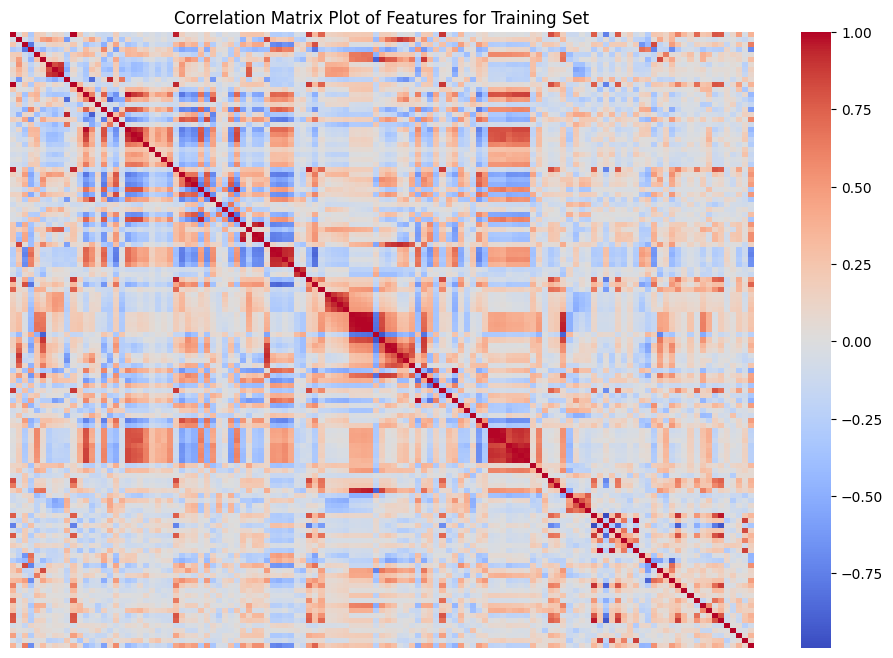

In [71]:
fit, axes = plt.subplots(figsize=(12, 8))
sns.heatmap(commt_data.corr(), cmap='coolwarm',
            xticklabels=False, yticklabels=False, ax=axes)
plt.title("Correlation Matrix Plot of Features for Training Set")
plt.show()

### (d) Calculate the Coeﬃcient of Variation CV for each feature, where CV=s/m , in which s is sample standard deviation and m is sample mean.

In [72]:
coef_of_vari = commt_data.apply(lambda col : col.std() / col.mean(), axis=0)
print(coef_of_vari)

population             2.203503
householdsize          0.353298
racepctblack           1.410920
racePctWhite           0.323782
racePctAsian           1.359162
                         ...   
LemasPctPolicOnPatr    0.306251
LemasGangUnitDeploy    0.921372
LemasPctOfficDrugUn    2.555266
PolicBudgPerPop        0.844368
ViolentCrimesPerPop    0.979015
Length: 123, dtype: float64


### (e) Pick ⌊√128⌋ features with highest CV, and make scatter plots and box plots for them. Can you draw conclusions about significance of those features, just by the scatter plots?

In [73]:
num_features = int(np.floor(np.sqrt(128)))
highCVfeats = coef_of_vari.sort_values(ascending=False)[:num_features]
highCVfeats

NumStreet              4.407702
NumInShelters          3.485481
NumIlleg               2.994196
NumImmig               2.900497
LemasPctOfficDrugUn    2.555266
NumUnderPov            2.304970
population             2.203503
numbUrban              2.001744
LemasSwornFT           1.984599
PctPolicAsian          1.979371
HousVacant             1.958780
dtype: float64

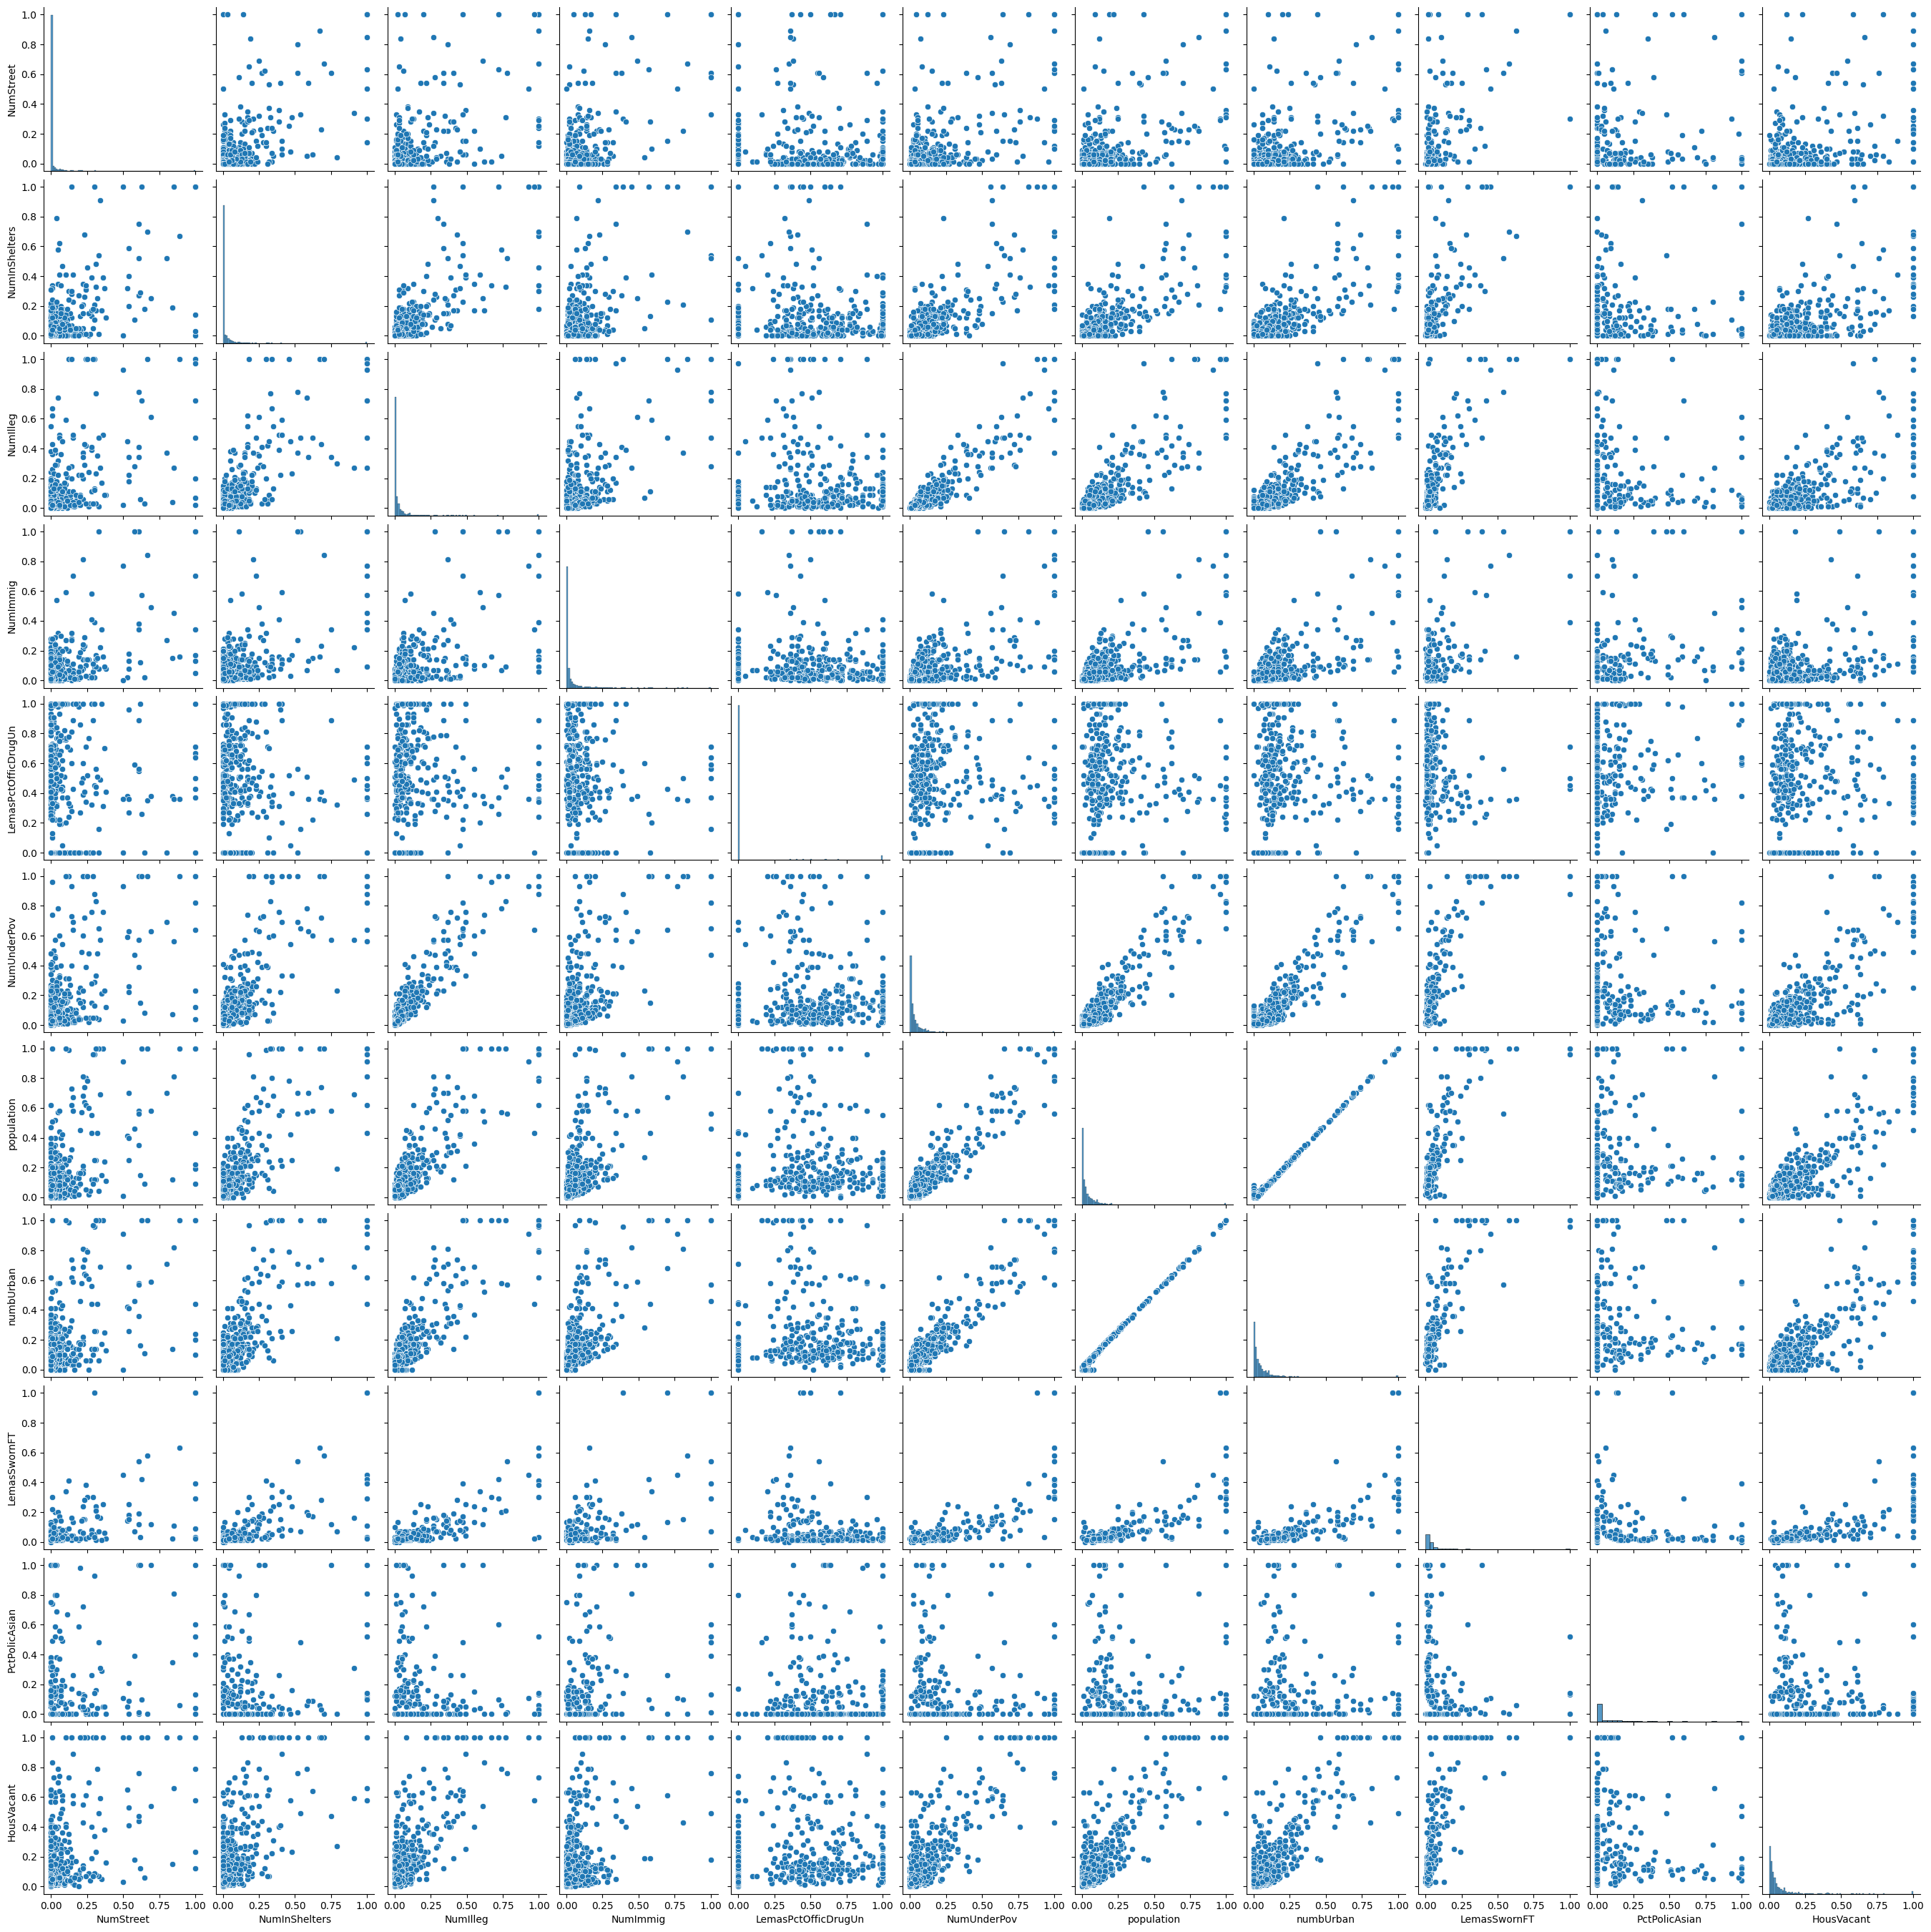

In [74]:
selected_cols = highCVfeats.index.tolist()
sns.pairplot(commt_data[selected_cols])
plt.show()

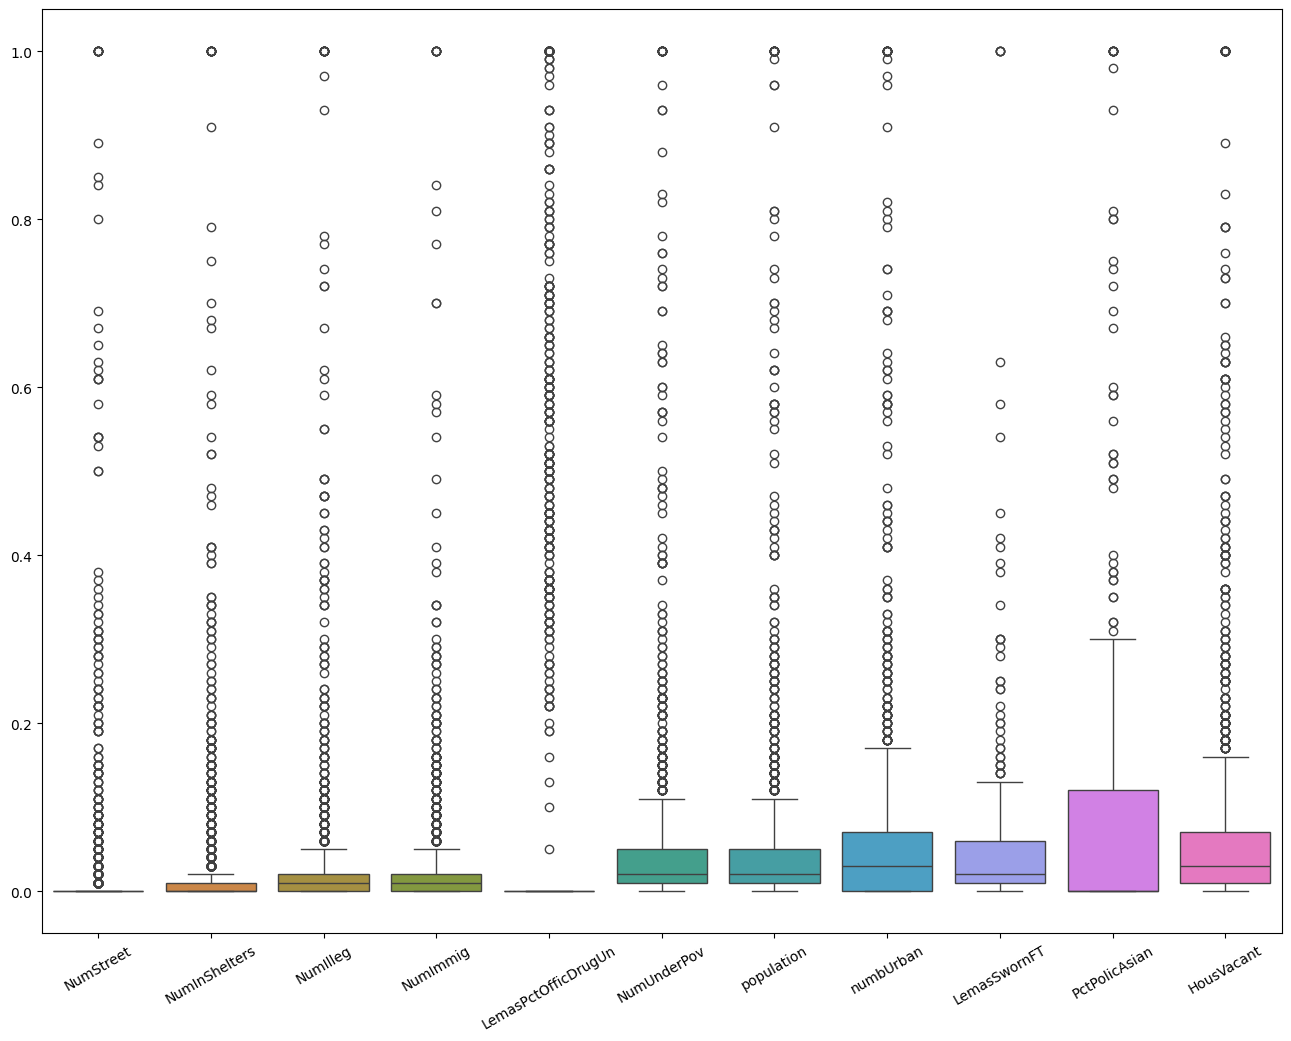

In [75]:
fig, axes = plt.subplots(figsize=(16, 12))
sns.boxplot(data=commt_data[selected_cols], ax=axes)
plt.xticks(rotation=30)
plt.show()

### (f) Fit a linear model using least squares to the training set and report the test error.

In [76]:
model_test_mse = {}

In [77]:
train_X = train_df.iloc[:, :-1]
train_Y = train_df.iloc[:, -1]

test_X = test_df.iloc[:, :-1]
test_Y = test_df.iloc[:, -1]

olsreg = LinearRegression()
olsreg.fit(train_X, train_Y)
test_pred = olsreg.predict(test_X)
test_mse = mean_squared_error(test_Y, test_pred)
model_test_mse["OLS"] = test_mse
print("OLS Linear Regression's test MSE:", test_mse)

OLS Linear Regression's test MSE: 0.017844644706157826


### (g) Fit a ridge regression model on the training set, with λchosen by cross-validation. Report the test error obtained.

In [78]:
splitter = KFold(5, shuffle=True, random_state=1495)


alphas = [10 ** i for i in range(-5, 6)]


ridge_model = RidgeCV(alphas=alphas, 
                      cv=splitter, 
                      scoring='neg_mean_squared_error')
ridge_model.fit(train_X, train_Y)
print("Choose alpha = {}".format(ridge_model.alpha_))

Choose alpha = 1.0


In [79]:
test_pred = ridge_model.predict(test_X)
test_mse = mean_squared_error(test_Y, test_pred)
model_test_mse["Ridge_Regression"] = test_mse
print("Ridge Regression's test MSE:", test_mse)

Ridge Regression's test MSE: 0.017502306931091532


### (h) Fit a LASSO model on the training set, with λ chosen by cross-validation. Report the test error obtained, along with a list of the variables selected by the model. Repeat with standardized features. Report the test error for both cases and compare them.

Note: In this data set, features are already normalized.

In [80]:
lasso_model = LassoCV(alphas=alphas, 
                      cv=splitter)
lasso_model.fit(train_X, train_Y)
print("Choose alpha = {}".format(lasso_model.alpha_))

Choose alpha = 0.0001


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.022e+00, tolerance: 6.559e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.404e-01, tolerance: 6.709e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, 

In [81]:
test_pred = lasso_model.predict(test_X)
test_mse = mean_squared_error(test_Y, test_pred)
model_test_mse["Lasso_w/o_std"] = test_mse
print("Without standardization, Lasso Regression's test MSE:", test_mse)
lasso_selecte_feature = pd.Series(data=lasso_model.coef_[lasso_model.coef_!=0],
                                  index=test_X.columns[lasso_model.coef_!=0])
print(lasso_selecte_feature)

Without standardization, Lasso Regression's test MSE: 0.01758385221993978
racepctblack           0.275387
racePctAsian          -0.014810
agePct12t21            0.078213
agePct12t29           -0.279285
agePct65up             0.011939
                         ...   
PctSameCity85          0.028100
LandArea               0.016662
PopDens                0.007536
PctUsePubTrans        -0.046075
LemasPctOfficDrugUn    0.009125
Length: 67, dtype: float64


In [82]:
scaler = StandardScaler()
std_train_X = scaler.fit_transform(train_X)
std_test_X = scaler.fit_transform(test_X)

std_train_X = pd.DataFrame(data=std_train_X, columns=train_X.columns)
std_test_X = pd.DataFrame(data=std_test_X, columns=test_X.columns)


lasso_model = LassoCV(alphas=alphas, 
                      cv=splitter)
lasso_model.fit(std_train_X, train_Y)
print("Choose alpha = {}".format(lasso_model.alpha_))

Choose alpha = 0.001


/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.650e-02, tolerance: 6.559e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.368e+00, tolerance: 6.559e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Users/umaeshwershankar/miniconda3/envs/mlds/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, 

In [83]:
test_pred = lasso_model.predict(std_test_X)
test_mse = mean_squared_error(test_Y, test_pred)
model_test_mse["Lasso_w_std"] = test_mse
print("With standardization, Lasso Regression's test MSE:", test_mse)
lasso_selecte_feature = pd.Series(data=lasso_model.coef_[lasso_model.coef_!=0],
                                  index=test_X.columns[lasso_model.coef_!=0])
print(lasso_selecte_feature)

With standardization, Lasso Regression's test MSE: 0.017710939343910607
population              -0.001318
racepctblack             0.067537
agePct12t21              0.005808
agePct12t29             -0.027356
pctUrban                 0.015397
pctWWage                -0.009828
pctWFarmSelf             0.003414
pctWInvInc              -0.015813
pctWSocSec               0.005282
pctWPubAsst              0.003295
pctWRetire              -0.014889
whitePerCap             -0.004651
blackPerCap             -0.003123
indianPerCap            -0.005016
AsianPerCap              0.004814
OtherPerCap              0.003792
HispPerCap               0.002939
PctPopUnderPov          -0.021052
PctLess9thGrade         -0.000525
PctEmploy                0.015509
MalePctDivorce           0.016556
MalePctNevMarr           0.015150
FemalePctDiv            -0.001859
PctKids2Par             -0.041631
PctYoungKids2Par        -0.008787
PctTeen2Par             -0.000512
PctWorkMom              -0.020014
NumIlleg  

### (i) Fit a PCR model on the training set, with M (the number of principal components) chosen by cross-validation. Report the test error obtained.

In [84]:
def PCRCV(train_X, train_Y, fold, dim):
    valid_err = 0

    splitter = KFold(fold, shuffle=True, random_state=1495)
    for train_idx, valid_idx in splitter.split(train_X):
        
        cur_trainX = train_X.iloc[train_idx, :]
        cur_trainY = train_Y.iloc[train_idx]
        cur_validX = train_X.iloc[valid_idx, :]
        cur_validY = train_Y.iloc[valid_idx]
        
        pca = PCA(n_components=dim).fit(cur_trainX)
        pca_train = pca.transform(cur_trainX)
        pca_valid = pca.transform(cur_validX)
       
        olsreg = LinearRegression()
        olsreg.fit(pca_train, cur_trainY)
        valid_pred = olsreg.predict(pca_valid)
        valid_mse = mean_squared_error(cur_validY, valid_pred)
        
        valid_err += valid_mse
    return valid_err / fold

In [85]:

avg_valid_err = []
for m in range(1, len(train_X.columns) + 1):
    valid_err = PCRCV(train_X, train_Y, 5, m)
    avg_valid_err.append((m, valid_err))


avg_valid_err.sort(key=lambda x: x[1])
print("When M = {}, the validation mse reach minimum of {}.".format(avg_valid_err[0][0],
                                                               avg_valid_err[0][1]))

When M = 87, the validation mse reach minimum of 0.019228522557120886.


In [86]:
pca = PCA(n_components=87).fit(train_X)


pca_train = pca.transform(train_X)
pca_test = pca.transform(test_X)


olsreg = LinearRegression().fit(pca_train, train_Y)
test_pred = olsreg.predict(pca_test)
test_mse = mean_squared_error(test_Y, test_pred)
model_test_mse["PCR"] = test_mse
print("PCR model's test MSE:", test_mse)

PCR model's test MSE: 0.01787412649505633


### (j) In this section, we would like to fit a boosting tree to the data. As in classification trees, one can use any type of regression at each node to build a multivariate regression tree. Because the number of variables is large in this problem, one can use L1-penalized regression at each node. Such a tree is called L1 penalized gradient boosting tree. You can use XGBoost to fit the model tree. Determine α (the regularization term) using cross-validation.

Note: Some hints on installing XGBoost on Windows: http://www.picnet.com.au/blogs/guido/2016/09/22/xgboost-windows-x64-binaries-for-download/

In [89]:
train_Dmatrix = xgb.DMatrix(data=train_X, label=train_Y)
test_Dmatrix = xgb.DMatrix(data=test_X)

avg_valid_err = []
alphas = [10 ** i for i in range(-10, 11)]


splitter = KFold(5, shuffle=True, random_state=1495)


for alpha in alphas:
    
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", reg_alpha=alpha)
    cvres = cross_val_score(xgb_model, train_X, train_Y, cv=splitter, 
                            scoring="neg_mean_squared_error")
    avg_valid_err.append((alpha, np.abs(cvres.mean())))


avg_valid_err.sort(key=lambda x: x[1])
print("When alpha = {}, the validation mse reaches minimum of {}.".format(avg_valid_err[0][0],
                                                               avg_valid_err[0][1]))

When alpha = 1, the validation mse reaches minimum of 0.021922269315435373.


In [90]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', reg_alpha=0.1).fit(train_X, train_Y)
test_pred = xgb_model.predict(test_X)
test_mse = mean_squared_error(test_Y, test_pred)
model_test_mse["XGBoost"] = test_mse
print("XGBoost model's test MSE:", test_mse)

XGBoost model's test MSE: 0.018743091441139333


In [91]:
model_test_mse = pd.DataFrame.from_dict(model_test_mse, orient='index', columns=['test_mse'])
model_test_mse

,test_mse
OLS,0.017845
Ridge_Regression,0.017502
Lasso_w/o_std,0.017584
Lasso_w_std,0.017711
PCR,0.017874
XGBoost,0.018743
